In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
np.random.seed(42)

n = 150

departments = np.random.choice(
    ["Data Science", "Analytics", "Finance", "HR", "Marketing"],
    size=n,
    p=[0.25, 0.25, 0.20, 0.15, 0.15]
)

gender = np.random.choice(
    ["Male", "Female"],
    size=n,
    p=[0.55, 0.45]
)

education = np.random.choice(
    ["Bachelor's", "Master's", "PhD"],
    size=n,
    p=[0.50, 0.40, 0.10]
)

employment_type = np.random.choice(
    ["Full Time", "Part Time", "Contract"],
    size=n,
    p=[0.70, 0.15, 0.15]
)

age = np.random.normal(31, 6, n).round().astype(int)
age = np.clip(age, 21, 50)

experience = np.maximum(
    0,
    age - 22 + np.random.normal(0, 2, n)
).round(1)

salary = (
    35000
    + experience * 4500
    + np.random.normal(0, 12000, n)
)
salary = np.maximum(salary, 28000).round(0)

performance = (
    5.8
    + experience * 0.12
    + np.random.normal(0, 1.1, n)
)
performance = np.clip(performance, 1, 10).round(1)

projects = np.maximum(
    1,
    experience * 0.7 + np.random.normal(4, 2.5, n)
).round().astype(int)

joining_dates = pd.date_range(
    start="2019-01-01",
    end="2025-12-01",
    periods=n
)

df = pd.DataFrame({
    "Department": departments,
    "Gender": gender,
    "Education": education,
    "Employment Type": employment_type,
    "Age": age,
    "Experience": experience,
    "Salary": salary,
    "Performance Score": performance,
    "Projects Completed": projects,
    "Joining Date": joining_dates
})

df.head()


,Department,Gender,Education,Employment Type,Age,Experience,Salary,Performance Score,Projects Completed,Joining Date
0,Analytics,Female,Bachelor's,Part Time,28,6.8,54207.0,6.8,7,2019-01-01 00:00:00.000000000
1,Marketing,Male,Master's,Full Time,26,7.8,101689.0,6.8,8,2019-01-17 22:52:20.939597315
2,HR,Male,Master's,Full Time,30,6.5,70170.0,5.1,8,2019-02-03 21:44:41.879194631
3,Finance,Male,Master's,Contract,25,0.5,39468.0,6.7,7,2019-02-20 20:37:02.818791946
4,Data Science,Female,Master's,Full Time,28,2.4,35500.0,6.8,7,2019-03-09 19:29:23.758389262


## Pair Plot

In [6]:
num_column = df.select_dtypes(include='number').columns.tolist()

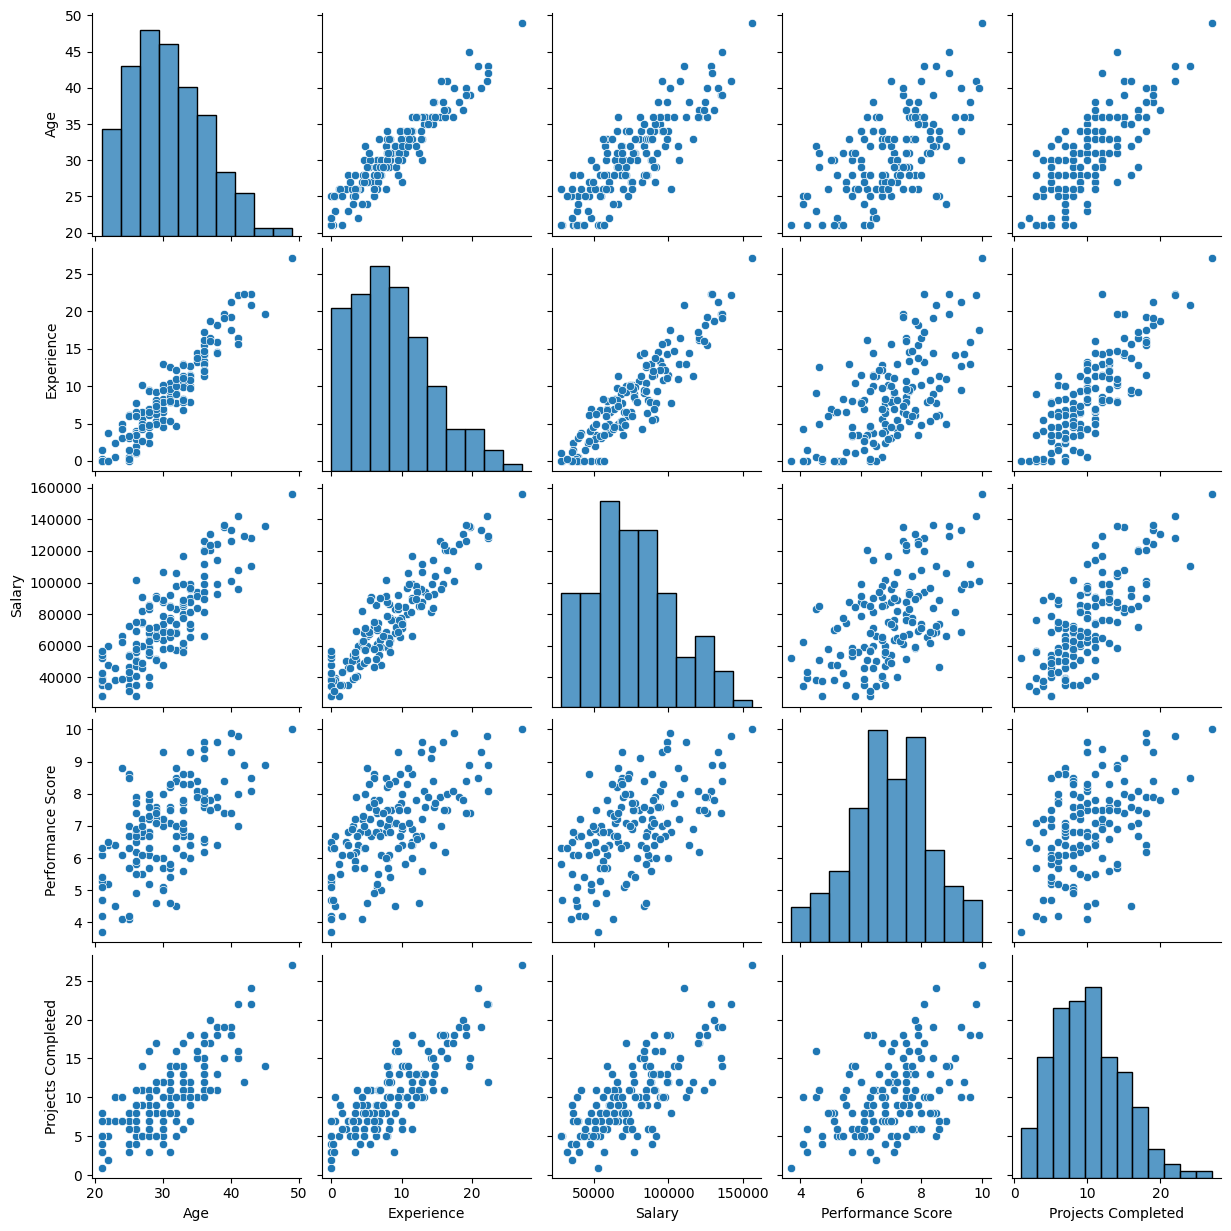

In [11]:
sns.pairplot(df[num_column])

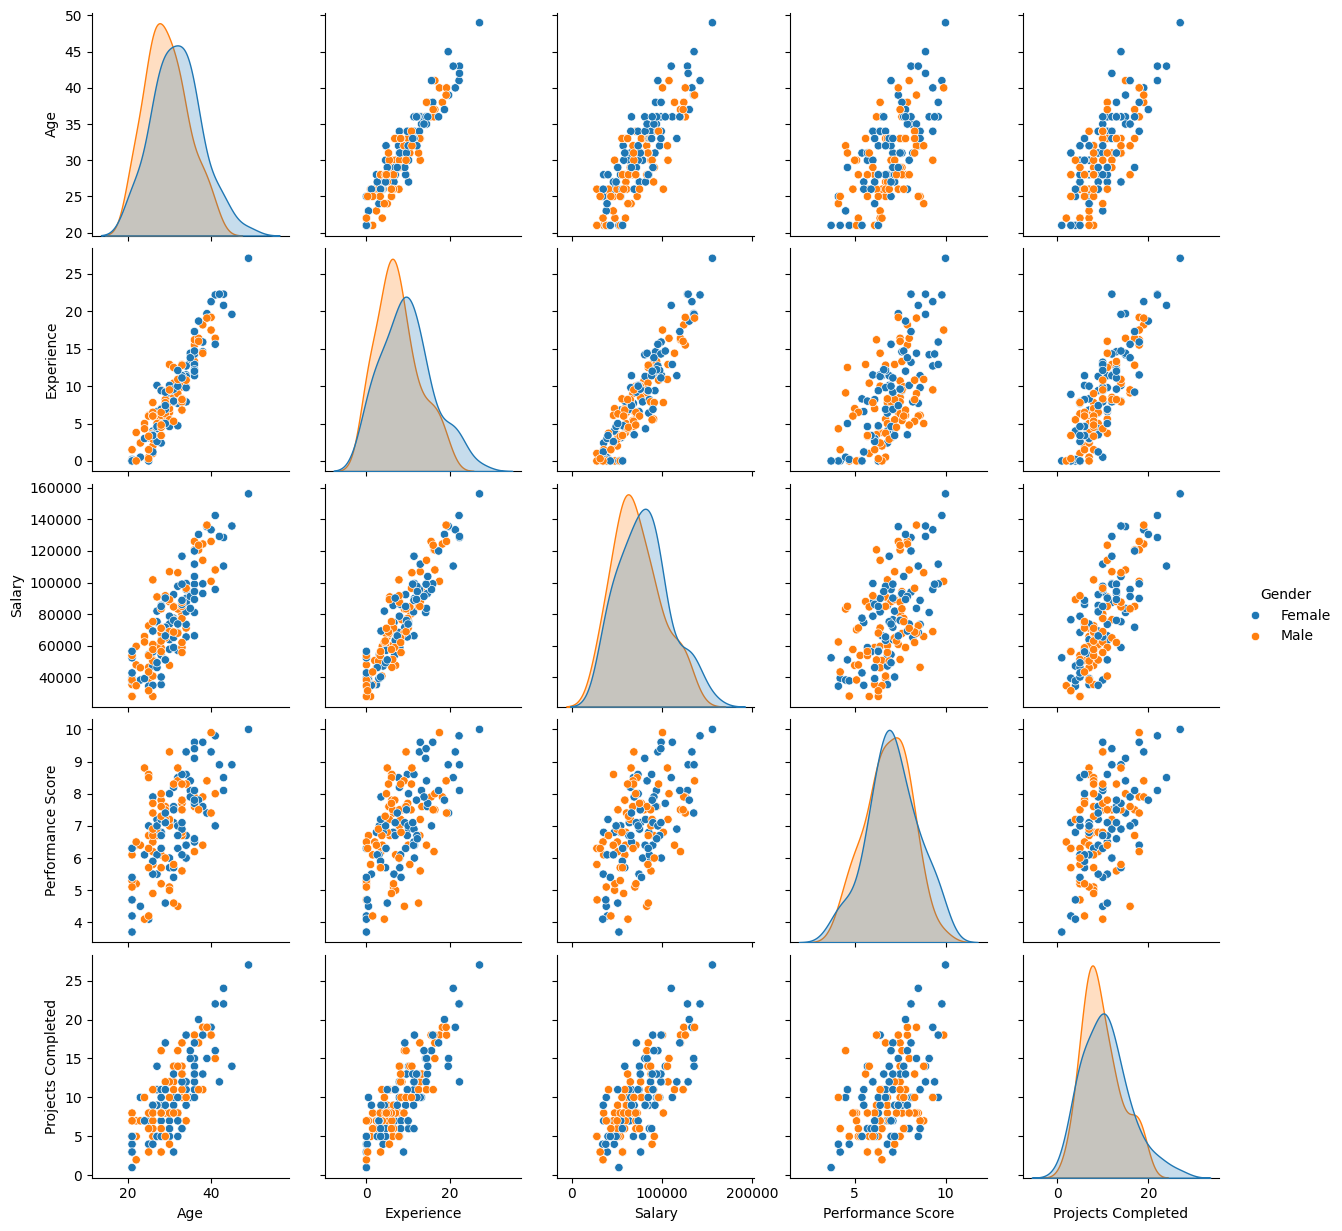

In [12]:
sns.pairplot(df,hue='Gender')

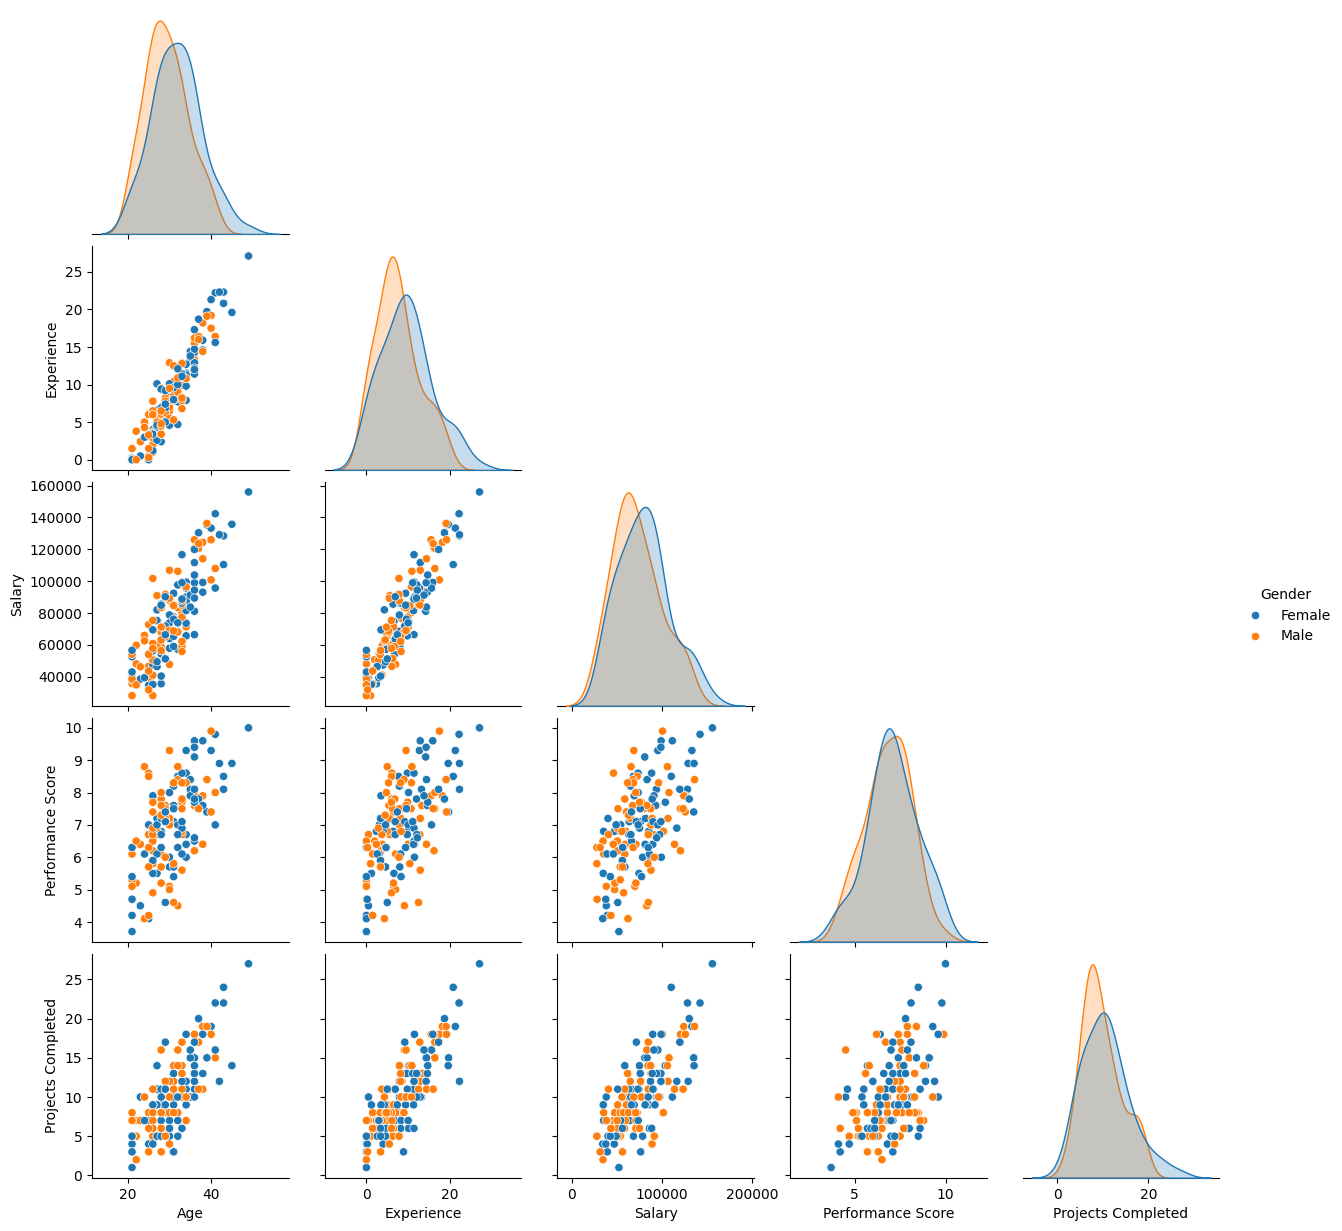

In [10]:
sns.pairplot(df,hue='Gender',corner=True)

## Scatter Plot

<Axes: xlabel='Age', ylabel='Salary'>

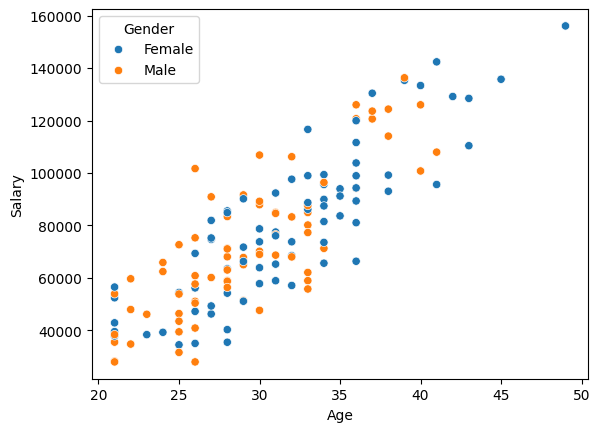

In [13]:
sns.scatterplot(data=df,x='Age',y='Salary',hue='Gender')

<Axes: xlabel='Age', ylabel='Salary'>

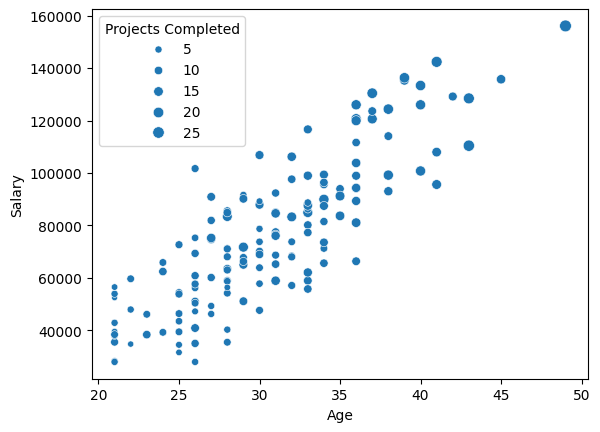

In [14]:
sns.scatterplot(data=df,x='Age',y='Salary',size='Projects Completed')

<Axes: xlabel='Age', ylabel='Salary'>

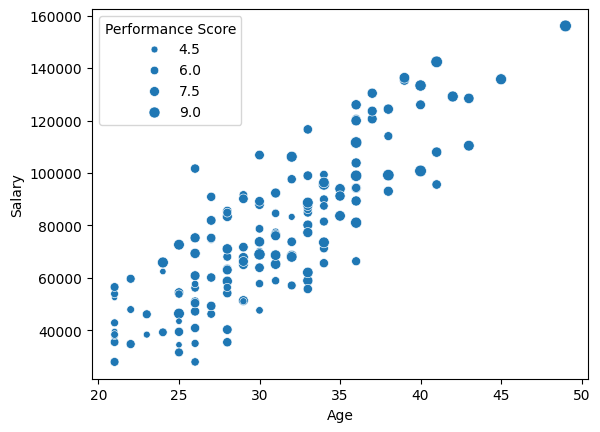

In [15]:
sns.scatterplot(data=df,x='Age',y='Salary',size='Performance Score')

## Correlation Matrix

In [20]:
df[num_column].corr()

,Age,Experience,Salary,Performance Score,Projects Completed
Age,1.000000,0.938560,0.839606,0.599068,0.768448
Experience,0.938560,1.000000,0.916971,0.615857,0.831329
Salary,0.839606,0.916971,1.000000,0.553833,0.756328
Performance Score,0.599068,0.615857,0.553833,1.000000,0.467726
Projects Completed,0.768448,0.831329,0.756328,0.467726,1.000000


In [18]:
corr_info = df[num_column].corr()

<Axes: >

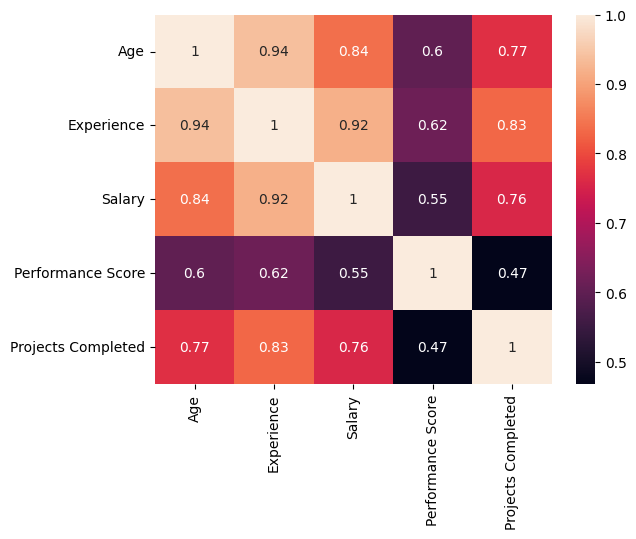

In [19]:
sns.heatmap(corr_info,annot=True)

## Grouped Variables

In [21]:
df.groupby(['Department','Education'])['Performance Score'].mean()

Department    Education 
Analytics     Bachelor's    6.933333
              Master's      7.306250
              PhD           7.650000
Data Science  Bachelor's    6.550000
              Master's      6.956250
              PhD           7.437500
Finance       Bachelor's    6.490909
              Master's      7.350000
              PhD           6.900000
HR            Bachelor's    7.171429
              Master's      6.825000
              PhD           6.000000
Marketing     Bachelor's    7.084615
              Master's      6.450000
              PhD           5.100000
Name: Performance Score, dtype: float64

In [22]:
perf_edu_dep = df.groupby(['Department','Education'])['Performance Score'].mean().reset_index()

In [23]:
perf_edu_dep

,Department,Education,Performance Score
0,Analytics,Bachelor's,6.933333
1,Analytics,Master's,7.306250
2,Analytics,PhD,7.650000
3,Data Science,Bachelor's,6.550000
4,Data Science,Master's,6.956250
5,Data Science,PhD,7.437500
6,Finance,Bachelor's,6.490909
7,Finance,Master's,7.350000
8,Finance,PhD,6.900000
9,HR,Bachelor's,7.171429


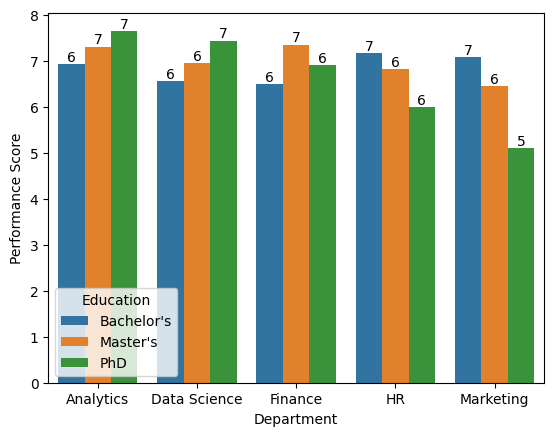

In [26]:
ax = sns.barplot(data=perf_edu_dep,x='Department',y='Performance Score',hue='Education')
for container in ax.containers:
    ax.bar_label(container,fmt='%d')

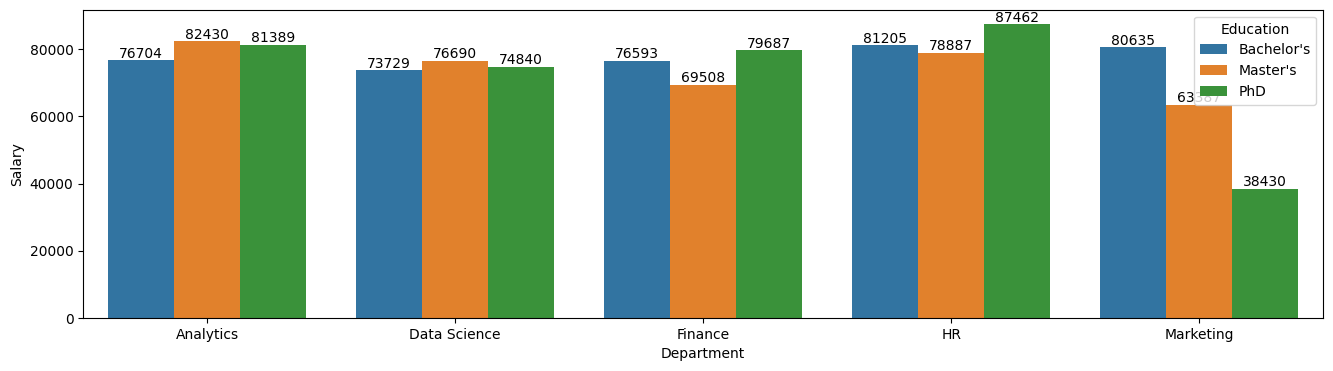

In [32]:
plt.figure(figsize=(16,4))
sal_edu_dep = df.groupby(['Department','Education'])['Salary'].mean().reset_index()
ax = sns.barplot(data=sal_edu_dep,x='Department',y='Salary',hue='Education',estimator='sum')
for container in ax.containers:
    ax.bar_label(container,fmt='%d')

<Axes: xlabel='Department', ylabel='Salary'>

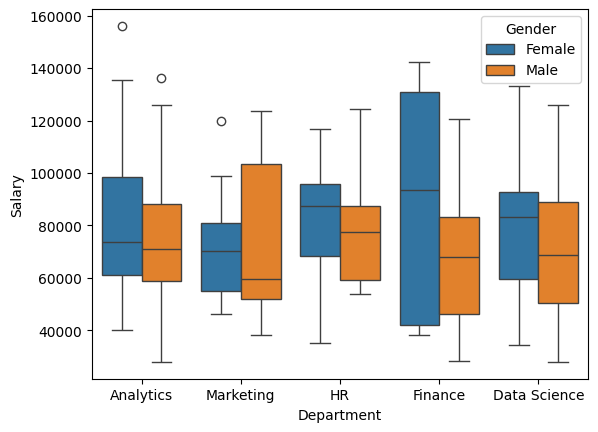

In [34]:
sns.boxplot(data=df,x='Department',y='Salary',hue='Gender')

In [35]:
pd.pivot_table(data=df,index='Department',columns='Gender',values='Salary',aggfunc='mean')

Gender,Female,Male
Department,,
Analytics,82734.631579,76482.210526
Data Science,78536.045455,71255.250000
Finance,89351.250000,65952.470588
HR,82990.384615,77656.400000
Marketing,71876.357143,73439.375000


In [37]:
new_cont = pd.pivot_table(data=df,index='Department',columns='Gender',values='Salary',aggfunc='sum')

<Axes: xlabel='Gender', ylabel='Department'>

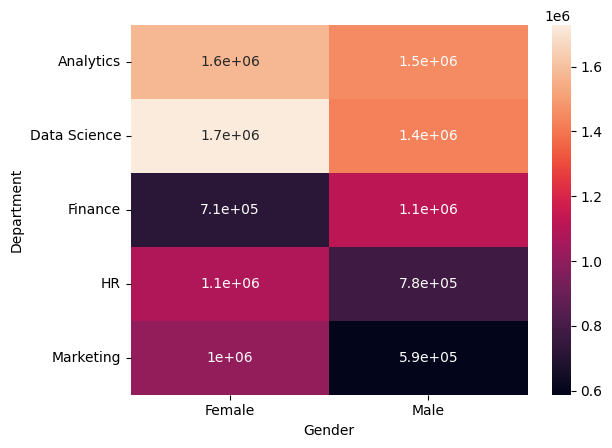

In [38]:
sns.heatmap(new_cont,annot=True)